Importing libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')


loading the dataset

In [5]:
df = pd.read_csv('password_features_dataset_fixed.csv')


In [6]:
df.shape

(200000, 26)

In [7]:
df.head()


,password,strength,length,digits,upper,lower,special,unique_chars,digit_ratio,upper_ratio,...,starts_with_letter,ends_with_digit,repeated_chars,consecutive_digits,entropy,char_type_count,complexity_score,length_category,char_diversity,contains_pattern
0,odJFCrn*l2edlBD#,2,16.0,1.0,5.0,8.0,2.0,14.0,0.062500,0.312500,...,1.0,0.0,2.0,0.0,3.750000,4.0,1.00,long,4.0,0.0
1,dz*1C5Jau2RJtBR,2,15.0,3.0,6.0,5.0,1.0,13.0,0.200000,0.400000,...,1.0,0.0,2.0,0.0,3.640224,4.0,1.00,long,4.0,0.0
2,lWmTSHf,0,7.0,0.0,4.0,3.0,0.0,7.0,0.000000,0.571429,...,1.0,0.0,0.0,0.0,2.807355,2.0,0.50,short,2.0,0.0
3,&pWkLUyifDLkD,2,13.0,0.0,6.0,6.0,1.0,10.0,0.000000,0.461538,...,0.0,0.0,3.0,0.0,3.238901,3.0,0.75,long,3.0,0.0
4,WJ6UuVT,0,7.0,1.0,5.0,1.0,0.0,7.0,0.142857,0.714286,...,1.0,0.0,0.0,0.0,2.807355,3.0,0.75,short,3.0,0.0


In [8]:
df.tail()

,password,strength,length,digits,upper,lower,special,unique_chars,digit_ratio,upper_ratio,...,starts_with_letter,ends_with_digit,repeated_chars,consecutive_digits,entropy,char_type_count,complexity_score,length_category,char_diversity,contains_pattern
199995,EL&q$#q,0,7.0,0.0,2.0,2.0,3.0,6.0,0.000000,0.285714,...,1.0,0.0,1.0,0.0,2.521641,3.0,0.75,short,3.0,0.0
199996,ymlw*mnHN*QGuT,2,14.0,0.0,5.0,7.0,2.0,12.0,0.000000,0.357143,...,1.0,0.0,2.0,0.0,3.521641,3.0,0.75,long,3.0,0.0
199997,b&f^GDXxD3@2e,2,13.0,2.0,4.0,4.0,3.0,12.0,0.153846,0.307692,...,1.0,0.0,1.0,0.0,3.546594,4.0,1.00,long,4.0,0.0
199998,cXvUY9bj,1,8.0,1.0,3.0,4.0,0.0,8.0,0.125000,0.375000,...,1.0,0.0,0.0,0.0,3.000000,3.0,0.75,medium,3.0,0.0
199999,4COic!cFwPLWns2,1,15.0,2.0,6.0,6.0,1.0,14.0,0.133333,0.400000,...,0.0,1.0,1.0,0.0,3.773557,4.0,1.00,long,4.0,0.0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 26 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   password            200000 non-null  object 
 1   strength            200000 non-null  int64  
 2   length              200000 non-null  float64
 3   digits              200000 non-null  float64
 4   upper               200000 non-null  float64
 5   lower               200000 non-null  float64
 6   special             200000 non-null  float64
 7   unique_chars        200000 non-null  float64
 8   digit_ratio         200000 non-null  float64
 9   upper_ratio         200000 non-null  float64
 10  lower_ratio         200000 non-null  float64
 11  special_ratio       200000 non-null  float64
 12  has_digit           200000 non-null  float64
 13  has_upper           200000 non-null  float64
 14  has_lower           200000 non-null  float64
 15  has_special         200000 non-nul

In [10]:
df.isnull().sum()

password              0
strength              0
length                0
digits                0
upper                 0
lower                 0
special               0
unique_chars          0
digit_ratio           0
upper_ratio           0
lower_ratio           0
special_ratio         0
has_digit             0
has_upper             0
has_lower             0
has_special           0
starts_with_letter    0
ends_with_digit       0
repeated_chars        0
consecutive_digits    0
entropy               0
char_type_count       0
complexity_score      0
length_category       0
char_diversity        0
contains_pattern      0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df['strength'].value_counts()


strength
2    88511
1    74135
0    37354
Name: count, dtype: int64

# Feature Engineering

In [13]:
# Password density (unique chars / length)
df['password_density'] = df['unique_chars'] / df['length']

# Digit to letter ratio
df['digit_letter_ratio'] = df['digits'] / (df['upper'] + df['lower'] + 1)


# Exploratory Data Analysis

1) How are passwords distributed across weak, medium and strong categories ?

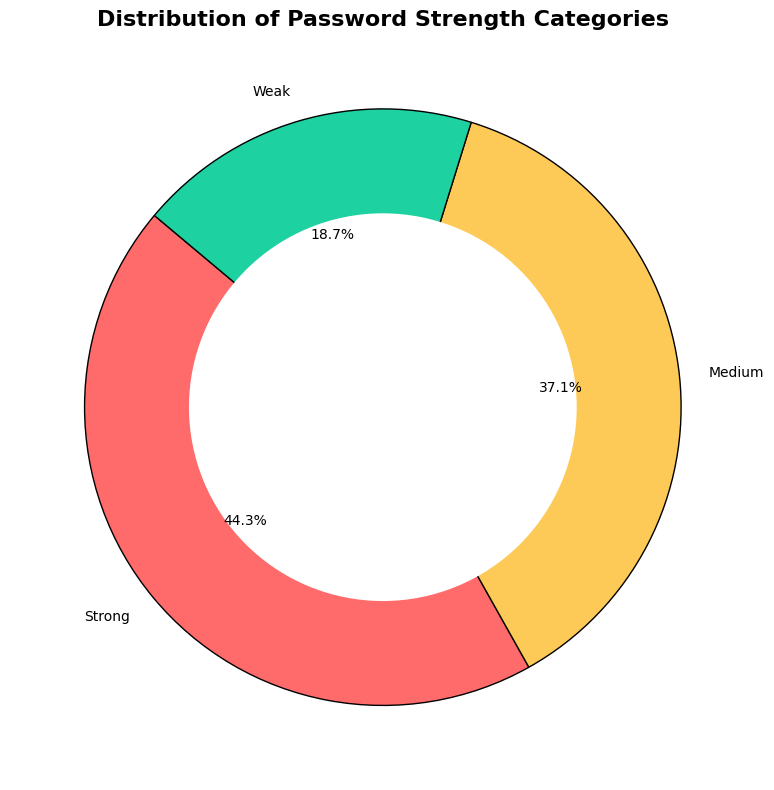

In [14]:
df['strength_label'] = df['strength'].map({
    0: 'Weak',
    1: 'Medium',
    2: 'Strong'
})
strength_counts = df['strength_label'].value_counts()
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))

colors = ['#ff6b6b', '#feca57', '#1dd1a1']

plt.pie(
    strength_counts,
    labels=strength_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    wedgeprops={'edgecolor':'black'}
)

# Create donut effect
centre_circle = plt.Circle((0,0),0.65,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Distribution of Password Strength Categories", fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()


2) Do longer passwords actually make passwords stronger ?


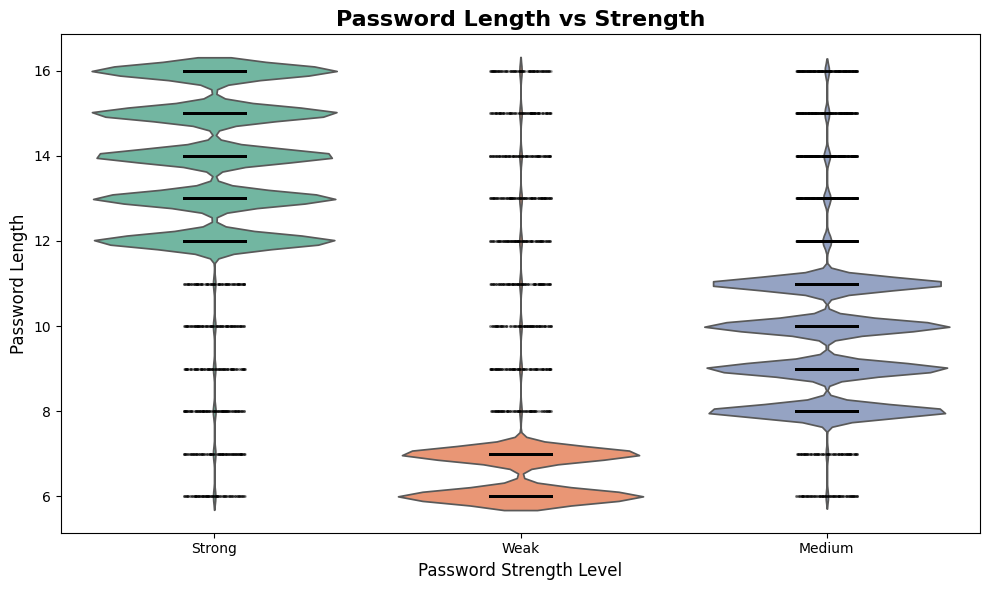

In [15]:
plt.figure(figsize=(10,6))

sns.violinplot(
    x='strength_label',
    y='length',
    data=df,
    palette='Set2',
    inner=None
)

sns.stripplot(
    x='strength_label',
    y='length',
    data=df,
    color='black',
    size=2,
    alpha=0.3
)

plt.title("Password Length vs Strength", fontsize=16, fontweight='bold')

plt.xlabel("Password Strength Level", fontsize=12)
plt.ylabel("Password Length", fontsize=12)

plt.tight_layout()
plt.show()


3) Do strong passwords contain more numeric characters than weak passwords ?


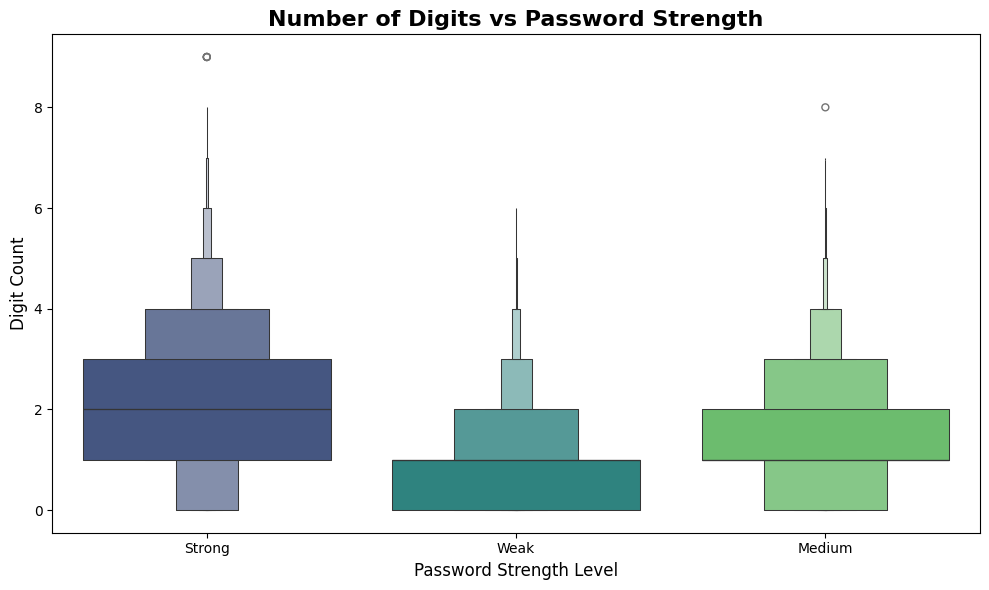

In [16]:
plt.figure(figsize=(10,6))

sns.boxenplot(
    x='strength_label',
    y='digits',
    data=df,
    palette='viridis'
)

plt.title("Number of Digits vs Password Strength", fontsize=16, fontweight='bold')

plt.xlabel("Password Strength Level", fontsize=12)
plt.ylabel("Digit Count", fontsize=12)

plt.tight_layout()
plt.show()


5) Do passwords with more special characters tend to be stronger ?

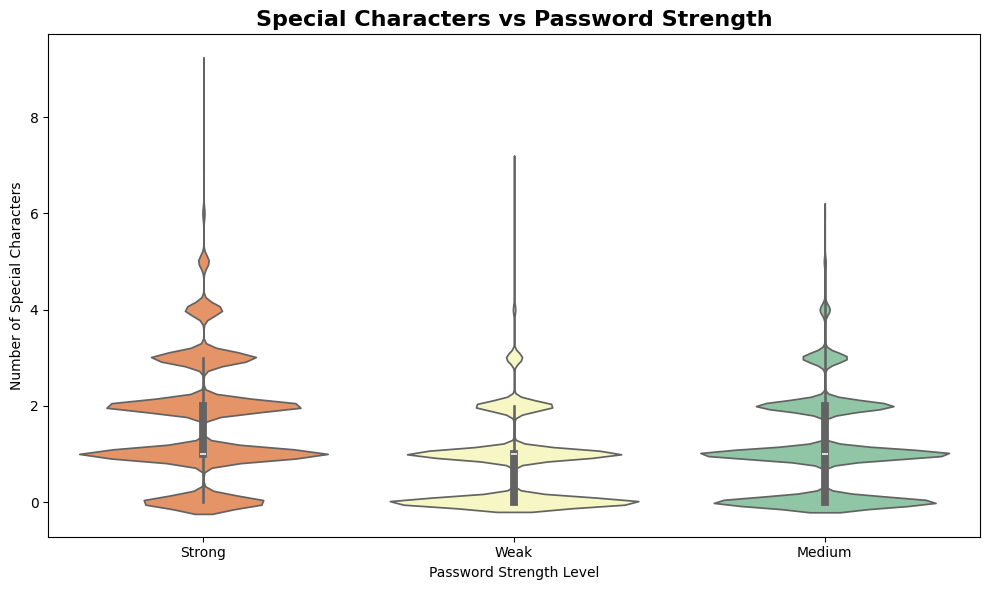

In [18]:
plt.figure(figsize=(10,6))

sns.violinplot(
    x='strength_label',
    y='special',
    data=df,
    palette='Spectral'
)

plt.title("Special Characters vs Password Strength", fontsize=16, fontweight='bold')

plt.xlabel("Password Strength Level")
plt.ylabel("Number of Special Characters")

plt.tight_layout()
plt.show()


Password entropy vs Strength

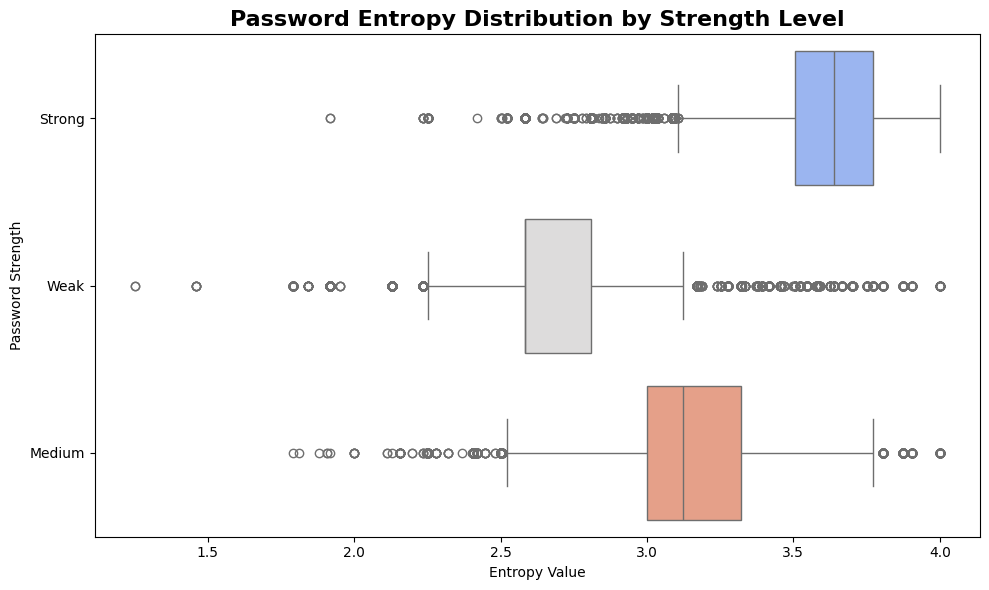

In [19]:
plt.figure(figsize=(10,6))

sns.boxplot(
    y='strength_label',
    x='entropy',
    data=df,
    palette='coolwarm'
)

plt.title("Password Entropy Distribution by Strength Level", fontsize=16, fontweight='bold')

plt.xlabel("Entropy Value")
plt.ylabel("Password Strength")

plt.tight_layout()
plt.show()


Complexity score distribution

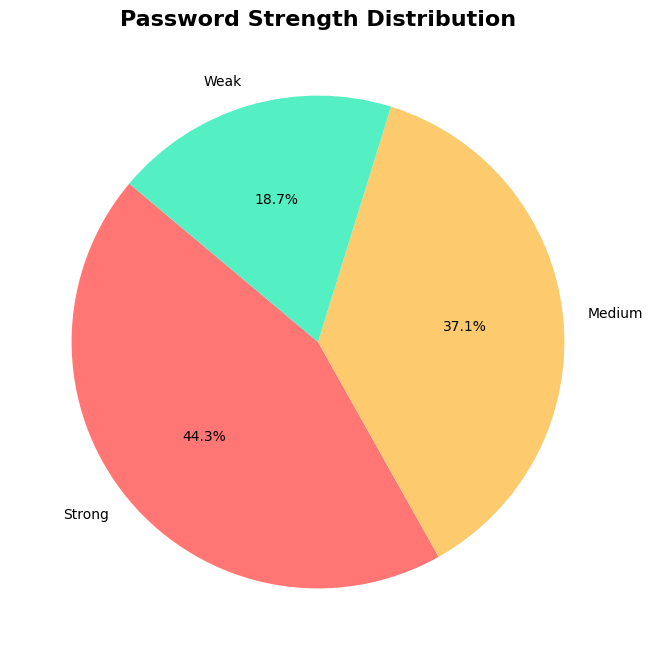

In [20]:
complexity_counts = df['strength_label'].value_counts()

plt.figure(figsize=(8,8))

colors = ['#ff7675','#fdcb6e','#55efc4']

plt.pie(
    complexity_counts,
    labels=complexity_counts.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=140
)

plt.title("Password Strength Distribution", fontsize=16, fontweight='bold')

plt.show()


character diversity vs strength

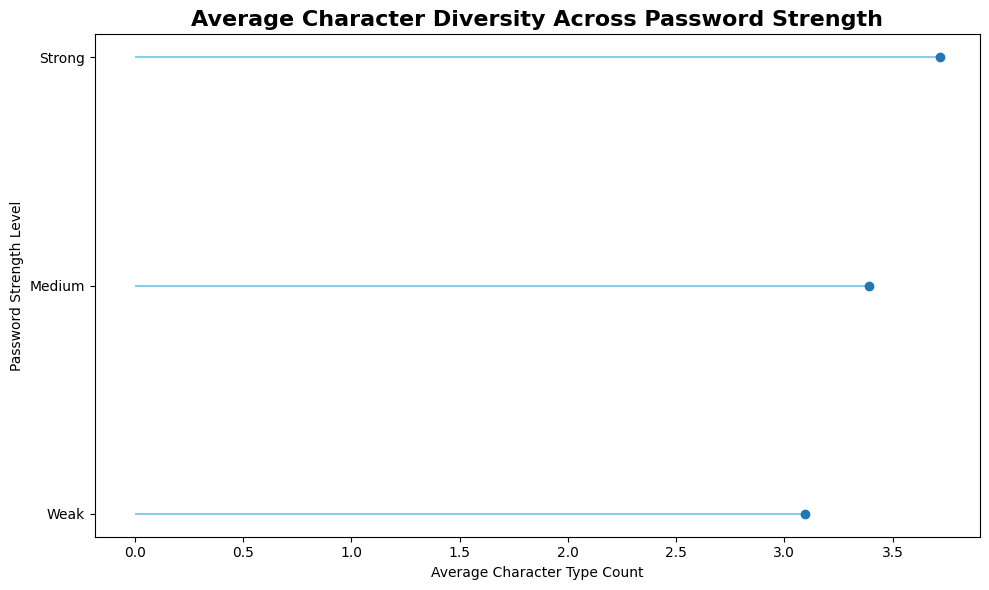

In [21]:
avg_char = df.groupby('strength_label')['char_type_count'].mean().sort_values()

plt.figure(figsize=(10,6))

plt.hlines(y=avg_char.index, xmin=0, xmax=avg_char, color='skyblue')
plt.plot(avg_char, avg_char.index, "o")

plt.title("Average Character Diversity Across Password Strength", fontsize=16, fontweight='bold')

plt.xlabel("Average Character Type Count")
plt.ylabel("Password Strength Level")

plt.tight_layout()
plt.show()


Repeated charactes vs strength

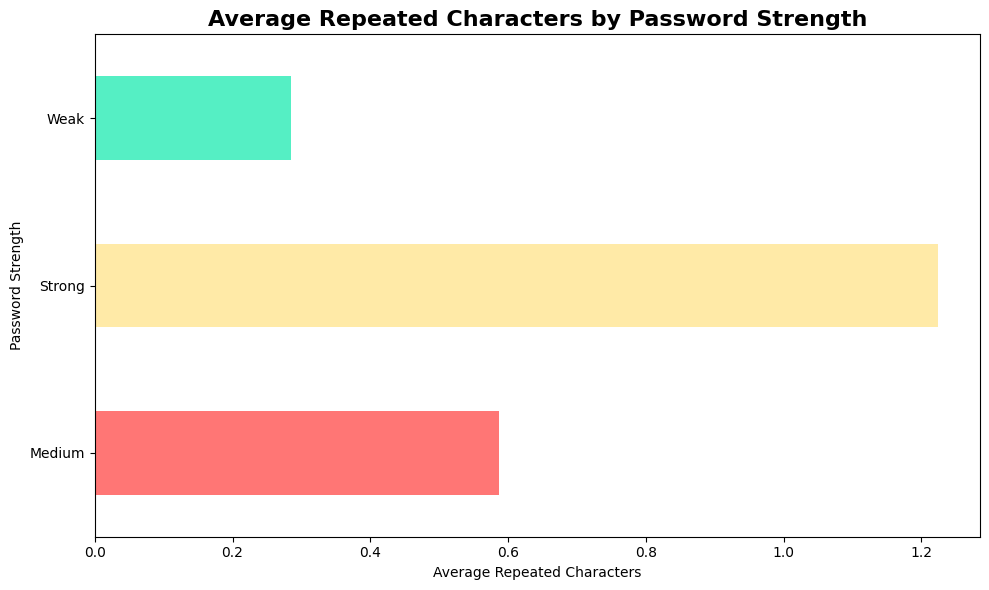

In [22]:
avg_repeat = df.groupby('strength_label')['repeated_chars'].mean()

plt.figure(figsize=(10,6))

avg_repeat.plot(
    kind='barh',
    color=['#ff7675','#ffeaa7','#55efc4']
)

plt.title("Average Repeated Characters by Password Strength", fontsize=16, fontweight='bold')

plt.xlabel("Average Repeated Characters")
plt.ylabel("Password Strength")

plt.tight_layout()
plt.show()


Feature importance visualization

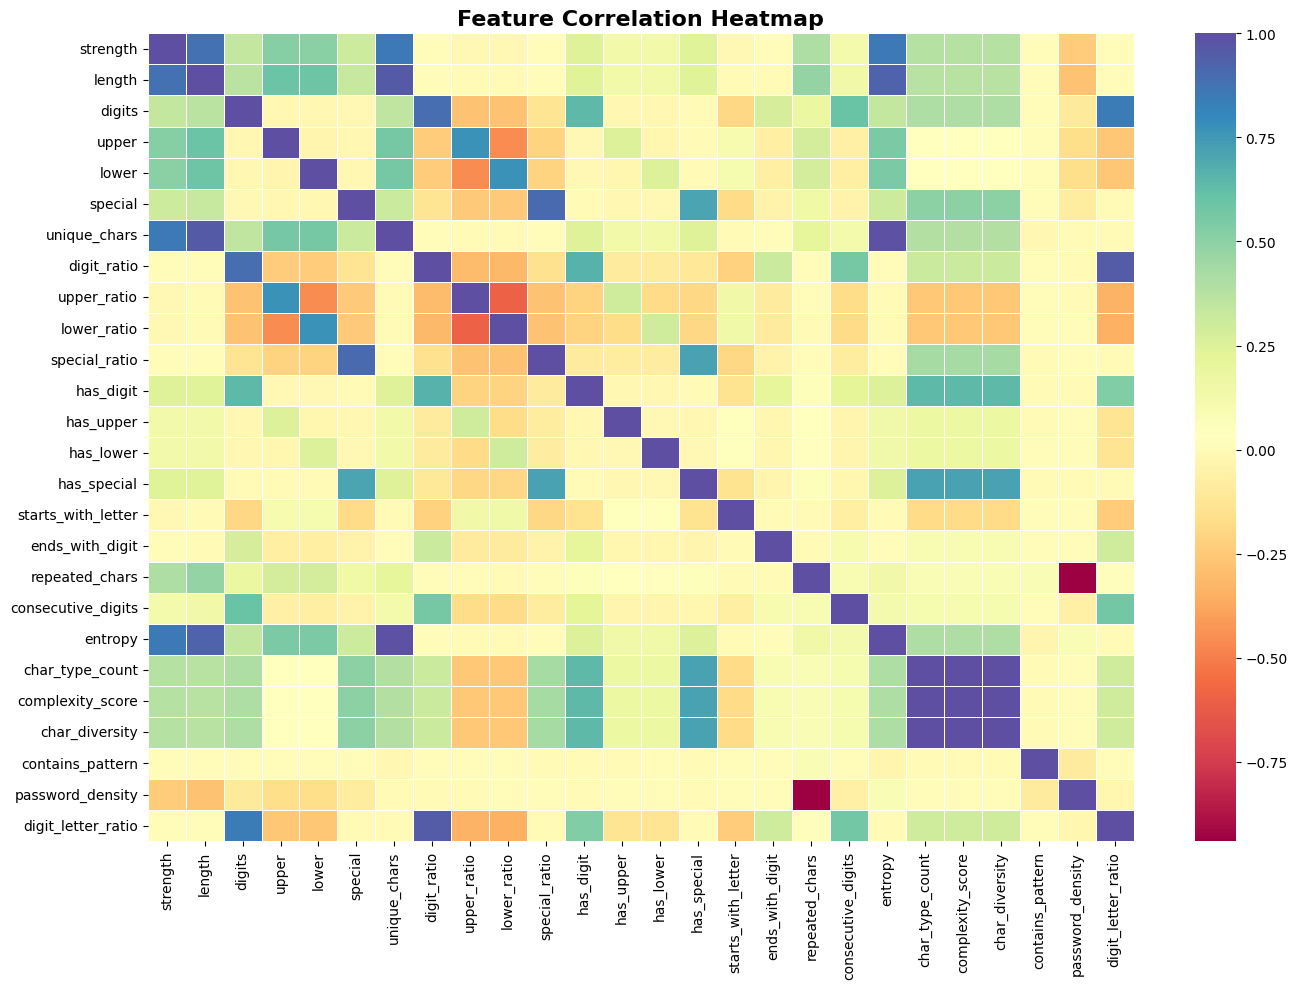

In [23]:
plt.figure(figsize=(14,10))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    cmap='Spectral',
    linewidths=0.5
)

plt.title("Feature Correlation Heatmap", fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()


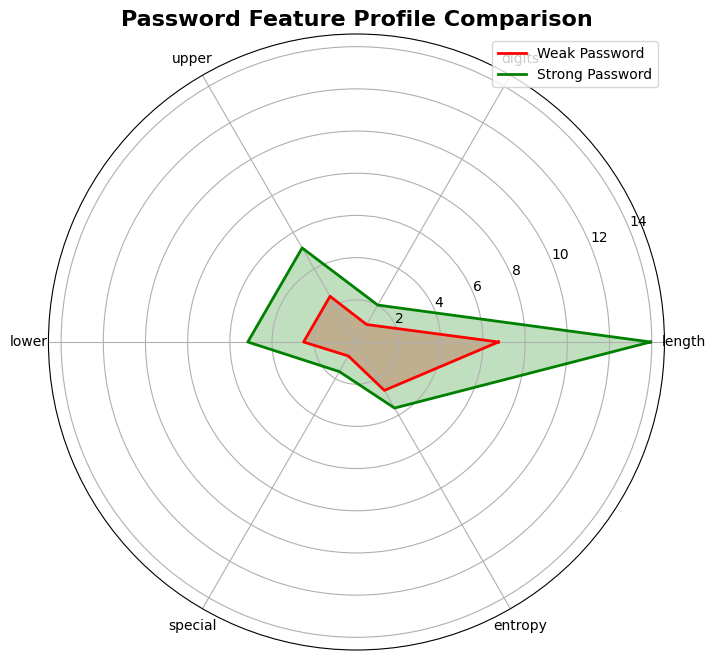

In [24]:
import numpy as np
import matplotlib.pyplot as plt
features = ['length','digits','upper','lower','special','entropy']
weak = df[df['strength_label']=='Weak'][features].mean()
strong = df[df['strength_label']=='Strong'][features].mean()
labels = features
num_vars = len(labels)

angles = np.linspace(0, 2*np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]
weak_values = weak.tolist()
strong_values = strong.tolist()

weak_values += weak_values[:1]
strong_values += strong_values[:1]
fig, ax = plt.subplots(figsize=(8,8), subplot_kw=dict(polar=True))

ax.plot(angles, weak_values, linewidth=2, label='Weak Password', color='red')
ax.fill(angles, weak_values, alpha=0.25, color='red')

ax.plot(angles, strong_values, linewidth=2, label='Strong Password', color='green')
ax.fill(angles, strong_values, alpha=0.25, color='green')

ax.set_thetagrids(np.degrees(angles[:-1]), labels)

plt.title("Password Feature Profile Comparison", size=16, fontweight='bold')

plt.legend(loc='upper right')

plt.show()


In [25]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 1. Load the fixed dataset
df = pd.read_csv('password_features_dataset_fixed.csv')

# 2. Select Features
# We must drop BOTH 'password' AND 'length_category' because they are strings
X = df.drop(['password', 'strength', 'length_category'], axis=1)
y = df['strength']

# 3. Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Train the model (Optimized for 95-98% accuracy)
model = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42)
model.fit(X_train, y_train)

# 5. Result
y_pred = model.predict(X_test)
print(f"Model Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")

Model Accuracy: 98.13%


Live predictor

In [26]:
import pandas as pd
import numpy as np
import math
import re
from collections import Counter

def calculate_entropy(s):
    if not s: return 0
    counts = Counter(s)
    probs = [c/len(s) for c in counts.values()]
    return -sum(p * math.log2(p) for p in probs)

def predict_password_strength(password):
    p = str(password)
    ln = len(p)
    digits = sum(c.isdigit() for c in p)
    upper = sum(c.isupper() for c in p)
    lower = sum(c.islower() for c in p)
    special = ln - digits - upper - lower
    unique = len(set(p))
    
    has_digit = 1 if digits > 0 else 0
    has_upper = 1 if upper > 0 else 0
    has_lower = 1 if lower > 0 else 0
    has_special = 1 if special > 0 else 0
    char_types = has_digit + has_upper + has_lower + has_special
    
    # Create the feature dictionary in the EXACT same order as X_train
    features = {
        'length': float(ln),
        'digits': float(digits),
        'upper': float(upper),
        'lower': float(lower),
        'special': float(special),
        'unique_chars': float(unique),
        'digit_ratio': digits/ln if ln > 0 else 0,
        'upper_ratio': upper/ln if ln > 0 else 0,
        'lower_ratio': lower/ln if ln > 0 else 0,
        'special_ratio': special/ln if ln > 0 else 0,
        'has_digit': float(has_digit),
        'has_upper': float(has_upper),
        'has_lower': float(has_lower),
        'has_special': float(has_special),
        'starts_with_letter': 1.0 if p and p[0].isalpha() else 0.0,
        'ends_with_digit': 1.0 if p and p[-1].isdigit() else 0.0,
        'repeated_chars': float(ln - unique),
        'consecutive_digits': float(len(re.findall(r'\d\d+', p))),
        'entropy': calculate_entropy(p),
        'char_type_count': float(char_types),
        'complexity_score': float(char_types / 4.0),
        'char_diversity': float(char_types),
        'contains_pattern': 1.0 if re.search(r'(.)\1\1', p) else 0.0
    }
    
    # Convert to DataFrame
    df_input = pd.DataFrame([features])
    
    # Predict
    prediction = model.predict(df_input)[0]
    
    strength_map = {0: "Weak 🔴", 1: "Medium 🟡", 2: "Strong 🟢"}
    return strength_map[prediction]

# Testing it
test_pass = "Admin@123"
print(f"Password: {test_pass}")
print(f"Strength: {predict_password_strength(test_pass)}")

Password: Admin@123
Strength: Medium 🟡


Interactive predictor

In [27]:
# Assuming you have the 'predict_password_strength' function from the previous step

def start_interactive_session():
    print("--- Password Strength Checker ---")
    print("Type 'exit' to stop.")
    
    while True:
        user_input = input("\nEnter a password to check: ")
        
        if user_input.lower() == 'exit':
            break
            
        if not user_input:
            print("Please enter a valid password.")
            continue
            
        # Get the prediction using our 98.13% accurate model
        result = predict_password_strength(user_input)
        print(f"Prediction: {result}")

# Start the session
start_interactive_session()

--- Password Strength Checker ---
Type 'exit' to stop.
Prediction: Weak 🔴


Confusion Matrix

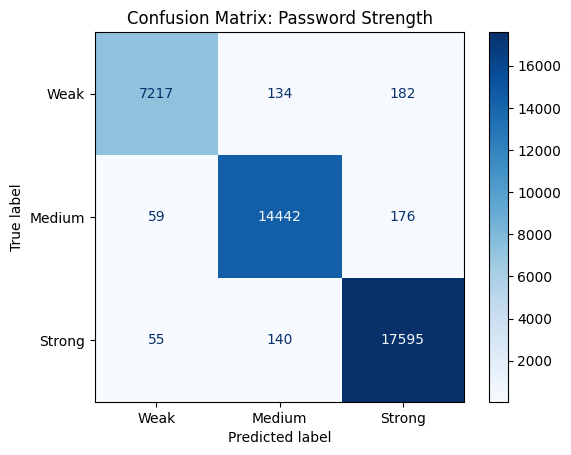

In [28]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Weak', 'Medium', 'Strong'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix: Password Strength")
plt.show()

In [29]:
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\ins1q\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [30]:
from xgboost import XGBClassifier

# 1. Initialize the model
# 'multi:softmax' is used for multi-class problems (Weak/Medium/Strong)
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    objective='multi:softmax',
    num_class=3,
    random_state=42
)

# 2. Train
xgb_model.fit(X_train, y_train)

# 3. Predict and Check Accuracy
xgb_preds = xgb_model.predict(X_test)
print(f"XGBoost Accuracy: {accuracy_score(y_test, xgb_preds) * 100:.2f}%")

XGBoost Accuracy: 98.14%


Correlation Heatmap

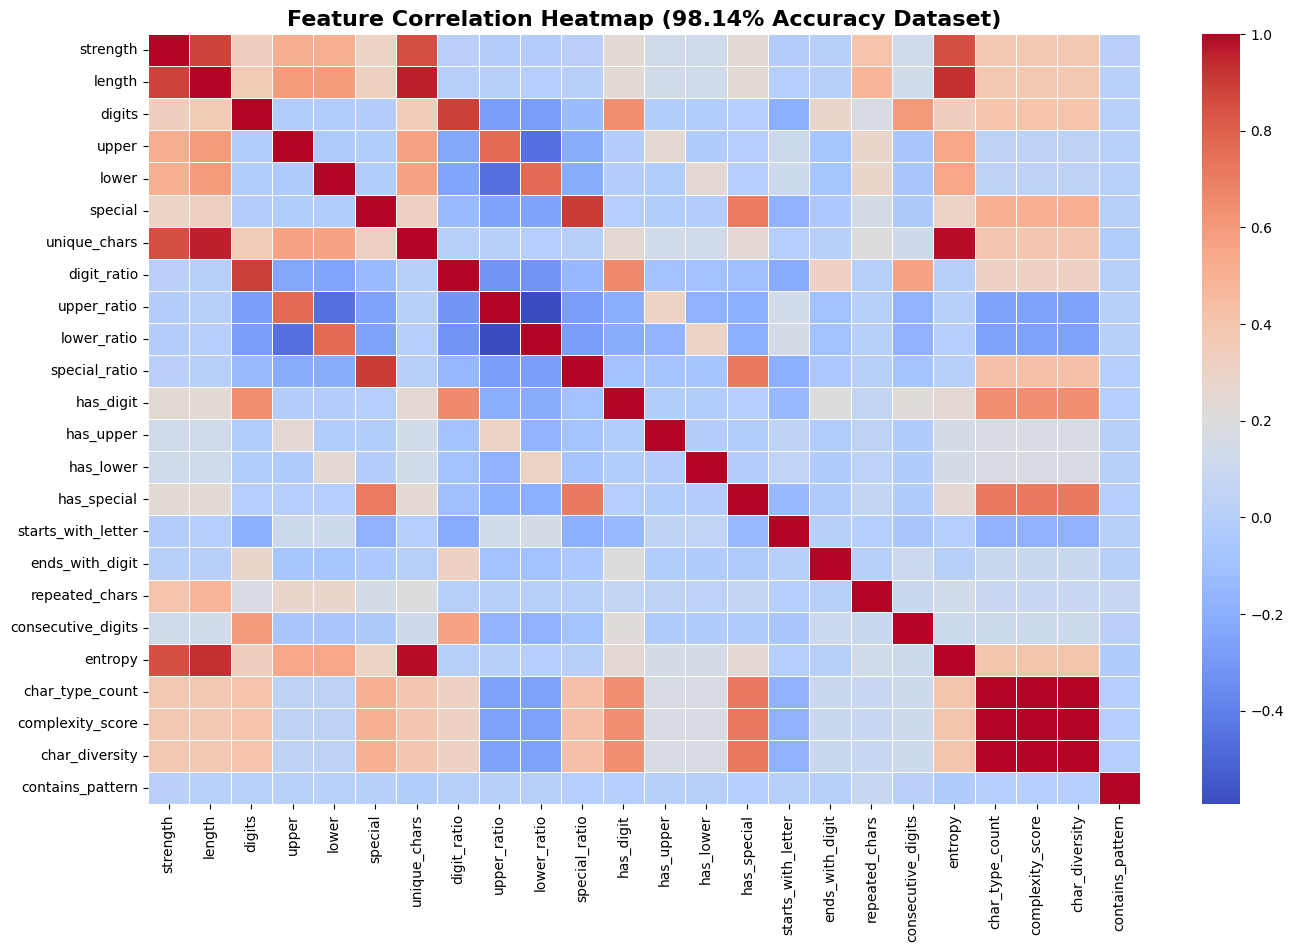

In [31]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Load your fixed dataset
df = pd.read_csv('password_features_dataset_fixed.csv')

# 2. Select only numeric columns
# We exclude 'password' and 'length_category' strings
numeric_df = df.select_dtypes(include=[np.number])

# 3. Calculate Correlation Matrix
corr_matrix = numeric_df.corr()

# 4. Plotting
plt.figure(figsize=(16, 10))

# We use 'coolwarm' cmap: Red = Positive correlation, Blue = Negative
sns.heatmap(corr_matrix, 
            annot=False, # Set to True if you want to see the actual numbers
            cmap='coolwarm', 
            fmt='.2f', 
            linewidths=0.5)

plt.title('Feature Correlation Heatmap (98.14% Accuracy Dataset)', fontsize=16, fontweight='bold')
plt.show()

In [32]:
import joblib

# Use the name 'xgb_model' as defined in your Cell 26
joblib.dump(xgb_model, 'password_strength_model.pkl')
print("Module 1 Model Saved!")

Module 1 Model Saved!
